# MISSION: filter out useless features, select or combine the most representative features.

In [1]:
# feature_file = {
#     "metadata": {...},
#     "features": {
#         "velocity_scale": ...,
#         "acceleration_scale": ...,
#         "velocity_xy": ...,
#         "acceleration_xy": ...,
#         "pol_vectors": ...,
#         "pol_distance": ...,
#         "pol_angles": ...,
#         "pol_distance_velocity": ...,
#         "pol_angular_velocity": ...,
#         "joint_angles": ...,
#         "ratios": ...,
#         "dist_ratios": ...,
#     },
#     "labels": {
#         "step_id": ...,
#         "step_id_prob": ...,
#         "status_id": ...,
#         "status_id_prob": ...,
#         "task_progress": ...,
#         "step_id_plateau": ...,
#         "step_id_plateau_prob": ...,
#         "status_id_plateau": ...,
#         "status_id_plateau_prob": ...,
#         "step_id_vector": ...,
#         "status_id_vector": ...,
#         "step_id_plateau_vector": ...,
#         "status_id_plateau_vector": ...,
#         "task_progress_vector": ...,
#     },
# }

In [1]:
import torch
import numpy as np
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif,mutual_info_regression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression

import shap

### flatten features + extract difference

In [2]:
def process_feature(name, val, prev_val=None):
    features = {}

    val = np.array(val)

    # ---------- scalar ----------
    if val.ndim == 0:
        features[name] = float(val)

        if prev_val is not None:
            diff = val - prev_val
            features[f"{name}_diff"] = float(diff)
            features[f"{name}_absdiff"] = float(abs(diff))

    # ---------- 2D vector ----------
    elif val.shape[-1] == 2:
        vx, vy = val
        mag = np.sqrt(vx**2 + vy**2)

        features[f"{name}_mag"] = float(mag)

        if prev_val is not None:
            pvx, pvy = prev_val
            prev_mag = np.sqrt(pvx**2 + pvy**2)

            diff = mag - prev_mag
            features[f"{name}_mag_diff"] = float(diff)
            features[f"{name}_mag_absdiff"] = float(abs(diff))

    # ---------- multi-dim ----------
    else:
        mean = np.mean(val)
        std = np.std(val)

        features[f"{name}_mean"] = float(mean)
        features[f"{name}_std"] = float(std)

        if prev_val is not None:
            prev_val = np.array(prev_val)
            prev_mean = np.mean(prev_val)

            diff = mean - prev_mean
            features[f"{name}_mean_diff"] = float(diff)
            features[f"{name}_mean_absdiff"] = float(abs(diff))

    return features

In [3]:
raw_pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\original"
pt_files = glob.glob(os.path.join(raw_pt_dir, "*01_take-01.pt"))

all_rows = []

for seq_id, pt_file in enumerate(pt_files):
    data = torch.load(pt_file)

    features = data["features"]
    labels = data["labels"]

    T = len(labels["step_id"])

    prev_frame = {}

    for t in range(T):
        row = {}

        for k, v in features.items():
            val = v[t]

            if hasattr(val, "detach"):
                val = val.detach().cpu().numpy()

            prev_val = prev_frame.get(k, None)

            processed = process_feature(k, val, prev_val)
            row.update(processed)

            prev_frame[k] = val

        row["step_id"] = int(labels["step_id"][t])
        row["step_id_prob"] = float(labels["step_id_prob"][t])
        row["t"] = t

        all_rows.append(row)

df = pd.DataFrame(all_rows)

print("Data shape:", df.shape)

Data shape: (7482, 50)


In [4]:
df.fillna(0, inplace=True)
df.head()

,velocity_scale_mean,velocity_scale_std,acceleration_scale_mean,acceleration_scale_std,velocity_xy_mean,velocity_xy_std,acceleration_xy_mean,acceleration_xy_std,pol_vectors_mean,pol_vectors_std,...,pol_distance_velocity_mean_diff,pol_distance_velocity_mean_absdiff,pol_angluer_velocity_mean_diff,pol_angluer_velocity_mean_absdiff,joint_angles_mean_diff,joint_angles_mean_absdiff,ratios_mag_diff,ratios_mag_absdiff,dist_ratios_mean_diff,dist_ratios_mean_absdiff
0,0.001760,0.000758,0.002643,0.001535,0.000142,0.001347,0.000079,0.002160,-0.028382,0.096707,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.001760,0.000758,0.002643,0.001535,0.000142,0.001347,0.000079,0.002160,-0.028349,0.096565,...,0.000000,0.000000,0.000000,0.000000,-0.064026,0.064026,-0.015143,0.015143,-0.004918,0.004918
2,0.001895,0.001218,0.002643,0.001535,0.000222,0.001577,0.000079,0.002160,-0.028502,0.095930,...,-0.000622,0.000622,-0.219715,0.219715,-1.020256,1.020256,-0.011929,0.011929,-0.009702,0.009702
3,0.003199,0.001038,0.003021,0.000840,0.001752,0.001608,0.001530,0.001605,-0.028867,0.095431,...,0.000064,0.000064,-0.112510,0.112510,-0.299438,0.299438,0.046190,0.046190,-0.018487,0.018487
4,0.003886,0.001288,0.002824,0.002563,0.001158,0.002654,-0.000595,0.002630,-0.028101,0.093494,...,-0.002052,0.002052,-0.827841,0.827841,0.426117,0.426117,0.057415,0.057415,0.010078,0.010078


# StandardScaler

In [5]:
#standardscaler 
scaler = StandardScaler()

#for feature columns
feature_cols = [col for col in df.columns if col not in ["step_id", "t","step_change"]]
df [feature_cols] = scaler.fit_transform(df[feature_cols])

df.head()


,velocity_scale_mean,velocity_scale_std,acceleration_scale_mean,acceleration_scale_std,velocity_xy_mean,velocity_xy_std,acceleration_xy_mean,acceleration_xy_std,pol_vectors_mean,pol_vectors_std,...,pol_distance_velocity_mean_diff,pol_distance_velocity_mean_absdiff,pol_angluer_velocity_mean_diff,pol_angluer_velocity_mean_absdiff,joint_angles_mean_diff,joint_angles_mean_absdiff,ratios_mag_diff,ratios_mag_absdiff,dist_ratios_mean_diff,dist_ratios_mean_absdiff
0,-0.378825,-0.559558,-0.140475,-0.313986,0.130467,-0.417981,0.061759,-0.185821,-0.300601,2.920638,...,-0.000051,-0.885005,0.000022,-0.371639,0.000124,-0.716311,0.000010,-0.138962,-0.000106,-0.710448
1,-0.378825,-0.559558,-0.140475,-0.313986,0.130467,-0.417981,0.061759,-0.185821,-0.297861,2.907830,...,-0.000051,-0.885005,0.000022,-0.371639,-0.020566,-0.690861,-0.003964,-0.134950,-0.221261,-0.439162
2,-0.311646,-0.338083,-0.140475,-0.313986,0.196444,-0.291696,0.061759,-0.185821,-0.310374,2.850408,...,-0.422538,-0.320826,-0.019204,-0.351129,-0.329571,-0.310760,-0.003120,-0.135801,-0.436381,-0.175280
3,0.334889,-0.424627,0.025450,-0.566218,1.467823,-0.275045,1.189046,-0.427039,-0.340239,2.805199,...,0.043491,-0.826861,-0.009823,-0.361136,-0.096640,-0.597284,0.012131,-0.126725,-0.831398,0.309279
4,0.675853,-0.304084,-0.061016,0.059302,0.973726,0.299195,-0.462019,0.018481,-0.277631,2.630062,...,-1.394802,0.977514,-0.072418,-0.294359,0.137823,-0.546930,0.015076,-0.123751,0.453054,-0.154567


In [6]:
df["step_id_prob"].describe()

count    7.482000e+03
mean    -1.025643e-16
std      1.000067e+00
min     -1.544643e+00
25%     -9.096481e-01
50%      7.216163e-02
75%      9.704621e-01
max      1.365033e+00
Name: step_id_prob, dtype: float64

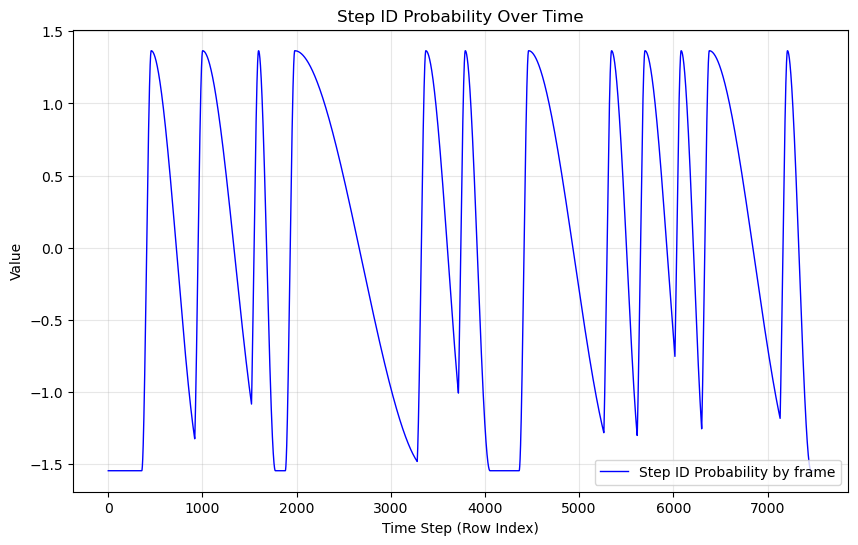

In [7]:
# plot distribution of step_id_prob 
plt.figure(figsize=(10, 6))

plt.plot(df.index, df['step_id_prob'], label='Step ID Probability by frame', color='blue', linewidth=1)

plt.title('Step ID Probability Over Time')
plt.xlabel('Time Step (Row Index)')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [8]:
bad_cols = [c for c in df.columns if df[c].dtype == "object"]
print("Object columns:", bad_cols)

Object columns: []


### Correlation

Text(0.5, 1.0, 'Feature Correlation Matrix')

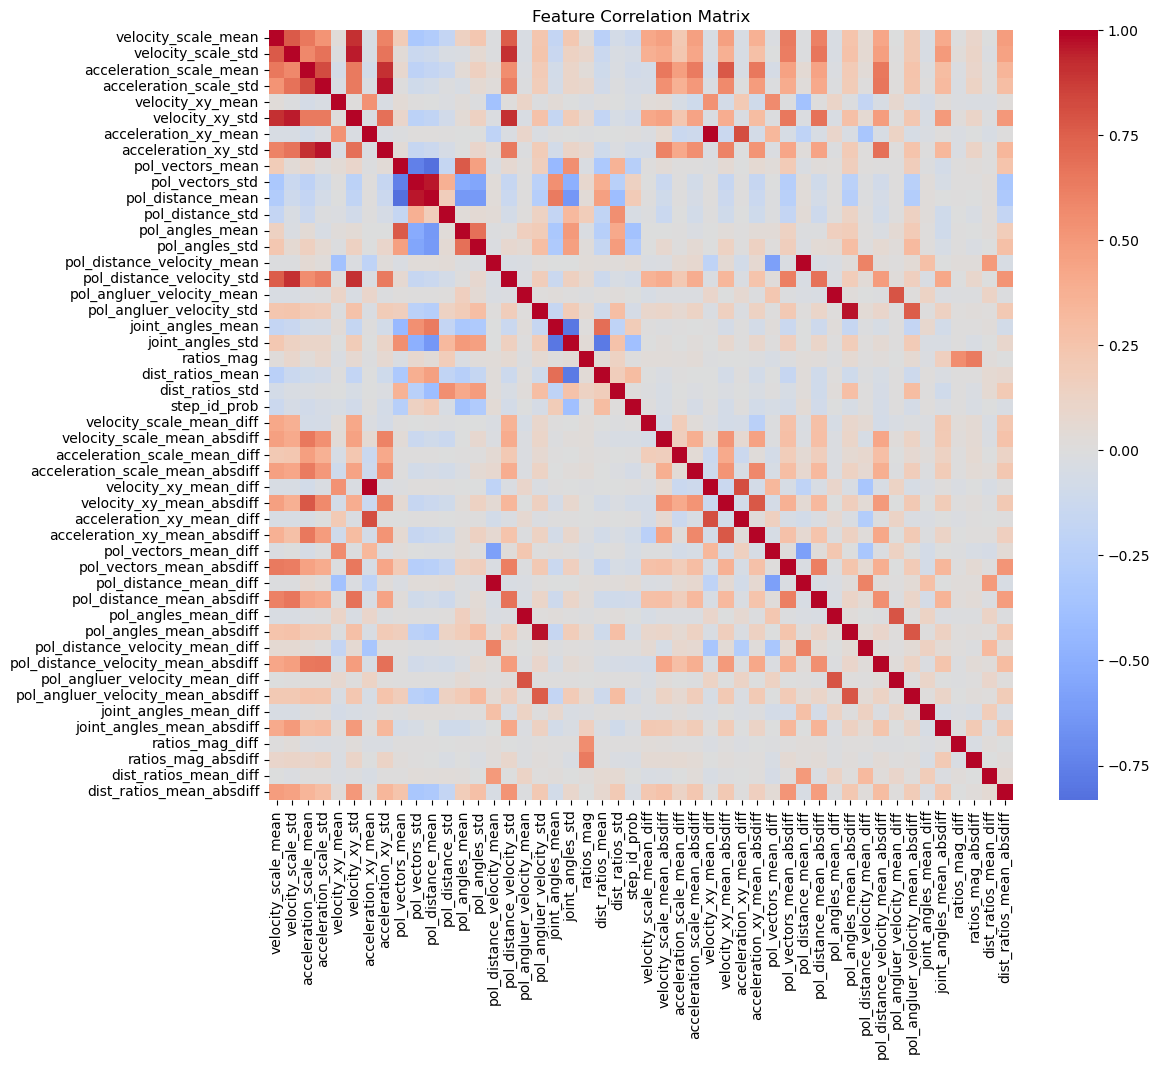

In [9]:
#correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")

### step_change signal: alignment

In [112]:
# df["step_change"] = df["step_id"].diff().fillna(0) != 0
# df["step_change"] = df["step_change"].astype(int)

# df.fillna(0, inplace=True)
# df.head()


In [113]:
# df["step_change"].describe()

In [114]:
# df["step_change"].sum()

In [10]:
df["step_id_prob"].describe()

count    7.482000e+03
mean    -1.025643e-16
std      1.000067e+00
min     -1.544643e+00
25%     -9.096481e-01
50%      7.216163e-02
75%      9.704621e-01
max      1.365033e+00
Name: step_id_prob, dtype: float64

In [11]:
df["step_id"].describe()

count    7482.000000
mean        3.216520
std         1.976443
min         0.000000
25%         1.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: step_id, dtype: float64

In [12]:
feature_cols = [c for c in df.columns if c not in ["step_id", "step_change", "t", "step_id_prob"]]

diff_cols = [c for c in feature_cols if "diff" in c]
absdiff_cols = [c for c in feature_cols if "absdiff" in c]

### Mutual Information

In [28]:
X = df[feature_cols]
y = df["step_id_prob"]

mi = mutual_info_regression(X.fillna(0), y)

mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

top_k = 20
top_features = mi_series.head(top_k).index

#CORE
X_filtered = X[top_features]

print("Top MI features:")
print(mi_series.head())

Top MI features:
pol_angles_mean      0.819903
pol_distance_mean    0.681634
pol_vectors_std      0.675235
pol_vectors_mean     0.640800
pol_angles_std       0.634844
dtype: float64


### Random Forest

In [30]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=5,
    min_samples_leaf=20,
)

model.fit(X_filtered.fillna(0), y)

feat_imp = pd.Series(model.feature_importances_, index=X_filtered.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top RF features:")
print(feat_imp.head())

Top RF features:
pol_angles_mean      0.294930
joint_angles_std     0.286608
joint_angles_mean    0.095715
pol_angles_std       0.079013
ratios_mag           0.052905
dtype: float64


In [31]:
len(X_filtered.columns)

20

### SHAP interaction analysis

In [35]:
background = X_filtered.sample(n=100, random_state=42)

 98%|===================| 1952/2000 [00:12<00:00]        

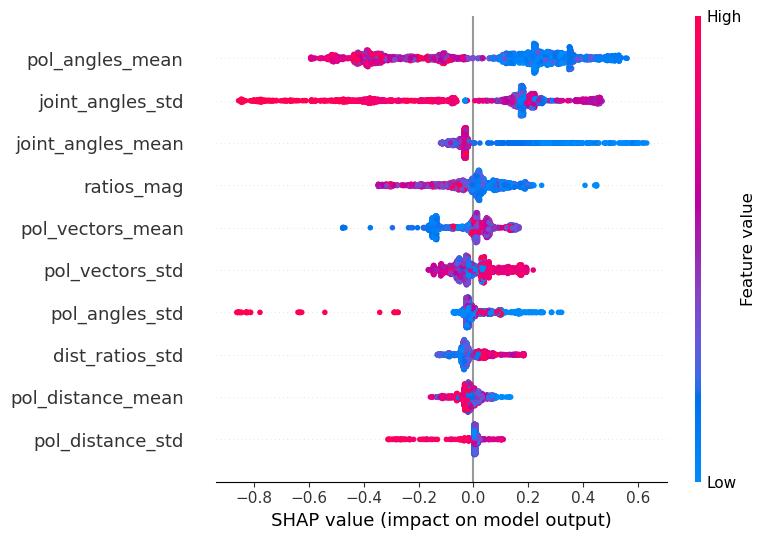

In [33]:
explainer = shap.TreeExplainer(model, background)

X_sample = X_filtered.sample(min(2000, len(X_filtered)), random_state=42)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample,max_display=10)

In [41]:

# shap_interaction_values = explainer_interaction.shap_interaction_values(X_sample[select_col])
# shap.summary_plot(shap_interaction_values, X_sample[select_col],max_display=10)

In [ ]:
# shap_importance = np.abs(shap_values).mean(axis=0)

In [42]:
# from itertools import combinations

# top_for_combo = feat_imp.head(10).index

# combo_features = pd.DataFrame(index=df.index)
# print("Creating top combo features...")
# print(top_for_combo)

# for f1, f2 in combinations(top_for_combo, 2):
#     combo_features[f"{f1}_minus_{f2}"] = df[f1] - df[f2]
#     combo_features[f"{f1}_ratio_{f2}"] = df[f1] / (df[f2] + 1e-6)


# X_aug = pd.concat([X_filtered, combo_features], axis=1)

# NOW WE CAN SAY THE MOST IMPACTFUL FEATURES ARE:

## pol_angles | joint_angles

--------------------------------------------------

## Pattern analysis based on the raw .pt data

In [81]:
# --- CONFIG ---
pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\original\*.pt"
pt_files = sorted(glob.glob(pt_dir))

print(f"Found {len(pt_files)} pt files.")

# --- storage ---
vel_list = []
acc_list = []
pol_vec_list = []
pol_ang_list = []
joint_list = []
ratio_list = []
dist_ratio_list = []
step_list = []

# --- helper ---
def to_2d(x):
    """
    shape = (T, D)
    """
    x = np.array(x)

    if x.ndim == 1:
        return x[:, None]  # (T,) -> (T,1)

    elif x.ndim == 2:
        return x  # already (T, D)

    else:
        return x.reshape(x.shape[0], -1)  # (T, ...)->(T, D)


# --- LOAD LOOP ---
for f in pt_files:
    data = torch.load(f)

    feats = data["features"]
    labels = data["labels"]

    try:
        vel = to_2d(feats["velocity_xy"])
        acc = to_2d(feats["acceleration_xy"])
        pol_vec = to_2d(feats["pol_vectors"])
        pol_ang = to_2d(feats["pol_angles"])
        joint = to_2d(feats["joint_angles"])
        ratio = to_2d(feats["ratios"])
        dist_ratio = to_2d(feats["dist_ratios"])

        step = np.array(labels["step_id"])

        vel_list.append(vel)
        acc_list.append(acc)
        pol_vec_list.append(pol_vec)
        pol_ang_list.append(pol_ang)
        joint_list.append(joint)
        ratio_list.append(ratio)
        dist_ratio_list.append(dist_ratio)
        step_list.append(step)

    except KeyError as e:
        print(f"Missing key in {f}: {e}")
        continue


# --- STACK ---
X_vel = np.vstack(vel_list)
X_acc = np.vstack(acc_list)
X_pol_vec = np.vstack(pol_vec_list)
X_pol_ang = np.vstack(pol_ang_list)
X_joint = np.vstack(joint_list)
X_ratio = np.vstack(ratio_list)
X_dist_ratio = np.vstack(dist_ratio_list)
y_step = np.hstack(step_list)

# --- COMBINATIONS ---

# movement
X_move = np.hstack([X_vel, X_acc])

# pose
X_combo = np.hstack([X_pol_ang, X_joint])

# full pose
X_pose_full = np.hstack([X_pol_vec, X_pol_ang, X_joint])

# ratio
X_ratio_comb = np.hstack([X_ratio, X_dist_ratio])

# all
X_all = np.hstack([
    X_vel,
    X_acc,
    X_pol_vec,
    X_pol_ang,
    X_joint,
    X_ratio,
    X_dist_ratio
])

# --- SCALING ---
##acc+joint angle
scaler_acc_joint = StandardScaler()
X_acc_joint_scaled = scaler_acc_joint.fit_transform(np.hstack([X_acc, X_joint]))

scaler_combo = StandardScaler()
X_combo_scaled = scaler_combo.fit_transform(X_combo)

scaler_move = StandardScaler()
X_move_scaled = scaler_move.fit_transform(X_move)

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# individual features scaling   
scaler_vel = StandardScaler()
X_vel_scaled = scaler_vel.fit_transform(X_vel)

scaler_acc = StandardScaler()
X_acc_scaled = scaler_acc.fit_transform(X_acc)

scaler_pol_vec = StandardScaler()
X_pol_vec_scaled = scaler_pol_vec.fit_transform(X_pol_vec)

scaler_pol_ang = StandardScaler()
X_pol_ang_scaled = scaler_pol_ang.fit_transform(X_pol_ang)

scaler_joint = StandardScaler()
X_joint_scaled = scaler_joint.fit_transform(X_joint)

scaler_ratio = StandardScaler()
X_ratio_scaled = scaler_ratio.fit_transform(X_ratio)

scaler_dist_ratio = StandardScaler()
X_dist_ratio_scaled = scaler_dist_ratio.fit_transform(X_dist_ratio)



# --- PRINT ---
print("\n--- Shapes ---")
print("vel:", X_vel.shape)
print("acc:", X_acc.shape)
print("pol_vec:", X_pol_vec.shape)
print("pol_ang:", X_pol_ang.shape)
print("joint:", X_joint.shape)
print("pose:", X_pose.shape)
print("all:", X_all.shape)

Found 6 pt files.

--- Shapes ---
vel: (56135, 26)
acc: (56135, 26)
pol_vec: (56135, 26)
pol_ang: (56135, 13)
joint: (56135, 7)
pose: (84466, 20)
all: (56135, 113)


##### add step segmentation info

In [73]:
import json
def overlay_pt_markers(ax, video_names, pt_dir, target_steps=100):
    """
    Draw step change markers from .pt files
    """
    for row_idx, video_base_name in enumerate(video_names):

        pt_file = os.path.join(pt_dir, f"{video_base_name}.pt")

        if not os.path.exists(pt_file):
            continue

        data = torch.load(pt_file)
        labels = data["labels"]

        step_id = np.array(labels["step_id"])
        T = len(step_id)

        # --- step change ---
        step_change = np.where(np.diff(step_id) != 0)[0] + 1

        for i, x in enumerate(step_change):

            color = "black" #if i % 2 == 0 else "red"

            x_pos = (x / T) * target_steps

            ax.vlines(
                x=x_pos,
                ymin=row_idx,
                ymax=row_idx + 1,
                color=color,
                linewidth=3,
                zorder=5
            )

### Determine which features are more representative and robust

In [26]:
# npz_norm_path = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\train\norm"
# json_label_path = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\annotations\all"

# Gaussion Mixture Models(GMMs)
### Distribution based

In [74]:
from sklearn.mixture import GaussianMixture

def plot_hybrid_feature_heatmap_pt(
    X_stacked,
    pt_dir,
    n_clusters=5,
    target_steps=100
):
    """
    GMM clustering + heatmap + step/prob markers (based on .pt)
    """

    # --- 1. load pt files ---
    pt_files = sorted([f for f in os.listdir(pt_dir) if f.endswith(".pt")])

    if not pt_files:
        print("No .pt files found.")
        return None, None

    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # --- 2. GMM ---
    print(f"Performing GMM clustering (K={n_clusters})...")

    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type='full',
        random_state=42,
        reg_covar=1e-6
    )

    global_labels = gmm.fit_predict(X_stacked)

    # --- 3. build matrix ---
    parallel_matrix = []
    video_names = []
    current_ptr = 0

    for pf in pt_files:

        pt_path = os.path.join(pt_dir, pf)
        data = torch.load(pt_path)

        video_name = os.path.basename(pf).replace(".pt", "")

        # --- determine T ---
        labels = data["labels"]
        num_frames = len(labels["step_id"])

        # --- slice cluster labels ---
        video_labels = global_labels[current_ptr: current_ptr + num_frames]
        current_ptr += num_frames

        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled = video_labels[indices]

            parallel_matrix.append(resampled)
            video_names.append(video_name)

    parallel_matrix = np.array(parallel_matrix)

    # --- 4. plot ---
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))

    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20", n_clusters)

    ax = sns.heatmap(
        parallel_matrix,
        cmap=cmap,
        xticklabels=10,
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)}
    )

    # --- 5. overlay markers ---
    overlay_pt_markers(ax, video_names, pt_dir, target_steps=target_steps)

    # --- 6. style ---
    plt.title(f"GMM Feature Pattern (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)

    plt.xticks(np.linspace(0, target_steps, 21),
               [f"{i*5}%" for i in range(21)])

    plt.tight_layout()
    plt.show()

    return ax, parallel_matrix

# DBSCAN
### Density based 

In [55]:
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap
#plot_hybrid_feature_heatmap(X_scaled_xyn, npz_norm_path, n_clusters=cluster)
def plot_hybrid_feature_heatmap(X_stacked, data_path, n_clusters):

    eps=0.5
    min_samples=10
    target_steps=100
    # 1. Get all .npz files
    npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
    if not npz_files:
        print(".npz files not found in the specified directory.")
        return None, None
        
    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # 2. Perform DBSCAN Clustering
    print(f"Performing DBSCAN clustering (eps={eps}, min_samples={min_samples})...")
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    global_labels = dbscan.fit_predict(X_stacked)

    # Calculate cluster statistics
    unique_labels = np.unique(global_labels)
    n_clusters_found = len([l for l in unique_labels if l >= 0])
    has_noise = -1 in unique_labels
    
    print(f"DBSCAN result: {n_clusters_found} clusters identified.")
    if has_noise:
        print(f"Noise detected (Label -1).")

    # 3. Construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 

    for pf in npz_files:
        data = np.load(pf)
        video_name = os.path.basename(pf).replace("_norm.npz", "")
        
        num_frames = data['X_degree'].shape[0]
        video_labels = global_labels[current_ptr : current_ptr + num_frames]
        current_ptr += num_frames
        
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. Prepare Heatmap and Color Mapping
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    # Custom colormap to handle -1 (Noise) as Grey
    base_n = max(1, n_clusters_found)
    base_cmap = plt.get_cmap("tab20", base_n)
    colors = [base_cmap(i) for i in range(base_n)]
    
    if has_noise:
        # Insert grey at the start for noise (-1)
        colors.insert(0, (0.5, 0.5, 0.5, 1.0)) 
        # Shift labels by +1 so that -1 becomes index 0 for the colormap
        plot_matrix = parallel_matrix + 1
        cbar_ticks = np.arange(n_clusters_found + 1)
        cbar_labels = ['Noise (-1)'] + [f'Cluster {i}' for i in range(n_clusters_found)]
    else:
        plot_matrix = parallel_matrix
        cbar_ticks = np.arange(n_clusters_found)
        cbar_labels = [f'Cluster {i}' for i in range(n_clusters_found)]

    my_cmap = ListedColormap(colors)

    # 5. Plot heatmap
    sns.heatmap(
        plot_matrix, 
        cmap=my_cmap, 
        xticklabels=10, 
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster Analysis', 'ticks': cbar_ticks}
    )
    
    # Update colorbar tick labels
    colorbar = plt.gca().collections[0].colorbar
    colorbar.set_ticklabels(cbar_labels)

    plt.title(f"DBSCAN Hybrid Feature Pattern Analysis (eps={eps})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return dbscan, parallel_matrix

# KMeans
### Centroid based

In [ ]:
# def plot_hybrid_feature_heatmap(X_stacked, data_path, json_label_path, n_clusters=5, target_steps=100):
#     # get all .npz files
#     npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
#     if not npz_files:
#         print(".npz files not found in the specified directory.")
#         return

#     # 2. global K-Means clustering on the stacked features
#     print("Performing K-Means clustering on combined features...")
    
#     # use different clustering methods here if needed(gaussion mixture, hierarchical clustering, etc.)
#     # KMEANS
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     global_labels = kmeans.fit_predict(X_stacked)

#     # 


#     # 3. construct parallel matrix for each video
#     parallel_matrix = []
#     video_names = []
#     current_ptr = 0 #

#     for pf in npz_files:
#         data = np.load(pf)
#         video_name = os.path.basename(pf).replace("_norm.npz", "")
        
#         # get number of frames for this video
#         num_frames = data['X_degree'].shape[0]
        
#         # extract corresponding cluster labels for this video's frames
#         video_labels = global_labels[current_ptr : current_ptr + num_frames]

#         current_ptr += num_frames
        
#         # align (Resampling to 0-100%)
#         if len(video_labels) > 0:
#             indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
#             resampled_labels = video_labels[indices]
            
#             parallel_matrix.append(resampled_labels)
#             video_names.append(video_name)

#     # 4. plot heatmap
#     parallel_matrix = np.array(parallel_matrix)
#     plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
#     cmap = plt.get_cmap("tab20", n_clusters)
#     ax = sns.heatmap(parallel_matrix, 
#                 cmap=cmap, 
#                 xticklabels=10, 
#                 yticklabels=video_names,
#                 cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)})
                
#     # --- insert labeled markers ---
#     if json_label_path is not None:
#         overlay_json_markers(ax, video_names, data_path, json_label_path, target_steps)
#     # -----------------------

#     plt.title(f"Hybrid Feature Pattern Analysis (K={n_clusters})", fontsize=15)
#     plt.xlabel("Task Progress (%)", fontsize=12)
#     plt.ylabel("Video Samples", fontsize=12)
    
#     # 5% interval ticks
#     plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
#     plt.tight_layout()
#     plt.show()

#     return ax, parallel_matrix

In [41]:
def plot_hybrid_feature_heatmap_pt(
    X_stacked,
    pt_dir,
    n_clusters=5,
    target_steps=100
):
    """
    K-Means clustering + heatmap + step/prob markers (based on .pt)
    """

    # --- 1. load pt files ---
    pt_files = sorted([f for f in os.listdir(pt_dir) if f.endswith(".pt")])

    if not pt_files:
        print("No .pt files found.")
        return None, None

    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # --- 2. K-Means ---
    print(f"Performing K-Means clustering (K={n_clusters})...")

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    global_labels = kmeans.fit_predict(X_stacked)

    # --- 3. build matrix ---
    parallel_matrix = []
    video_names = []
    current_ptr = 0

    for pf in pt_files:

        pt_path = os.path.join(pt_dir, pf)
        data = torch.load(pt_path)

        video_name = os.path.basename(pf).replace(".pt", "")

        # --- determine T ---
        labels = data["labels"]
        num_frames = len(labels["step_id"])

        # --- slice cluster labels ---
        video_labels = global_labels[current_ptr: current_ptr + num_frames]
        current_ptr += num_frames

        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled = video_labels[indices]

            parallel_matrix.append(resampled)
            video_names.append(video_name)

    parallel_matrix = np.array(parallel_matrix)

    # --- 4. plot ---
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))

    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20", n_clusters)

    ax = sns.heatmap(
        parallel_matrix,
        cmap=cmap,
        xticklabels=10,
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)}
    )

    # --- 5. overlay markers ---
    overlay_pt_markers(ax, video_names, pt_dir, target_steps=target_steps)

    # --- 6. style ---
    plt.title(f"K-Means Feature Pattern (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)

    plt.xticks(np.linspace(0, target_steps, 21),
               [f"{i*5}%" for i in range(21)])

    plt.tight_layout()
    plt.show()

    return ax, parallel_matrix

In [75]:
cluster = 5

# Individual Features

In [ ]:
    # X_stacked,
    # pt_dir,
    # n_clusters=5,
    # target_steps=100,
    # use_prob=False

In [98]:
pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\original"

Performing GMM clustering (K=7)...


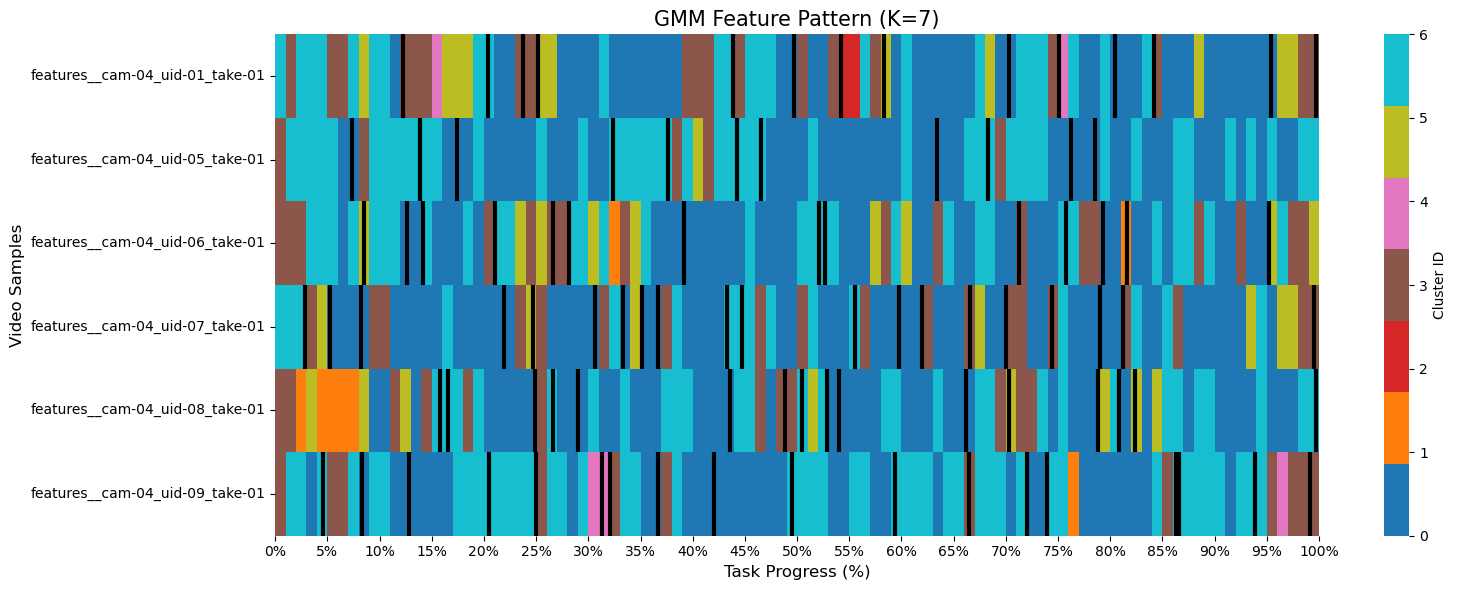

In [96]:
# pol angle
ax_pol_ang, matrix_pol_ang = plot_hybrid_feature_heatmap_pt(X_pol_ang_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


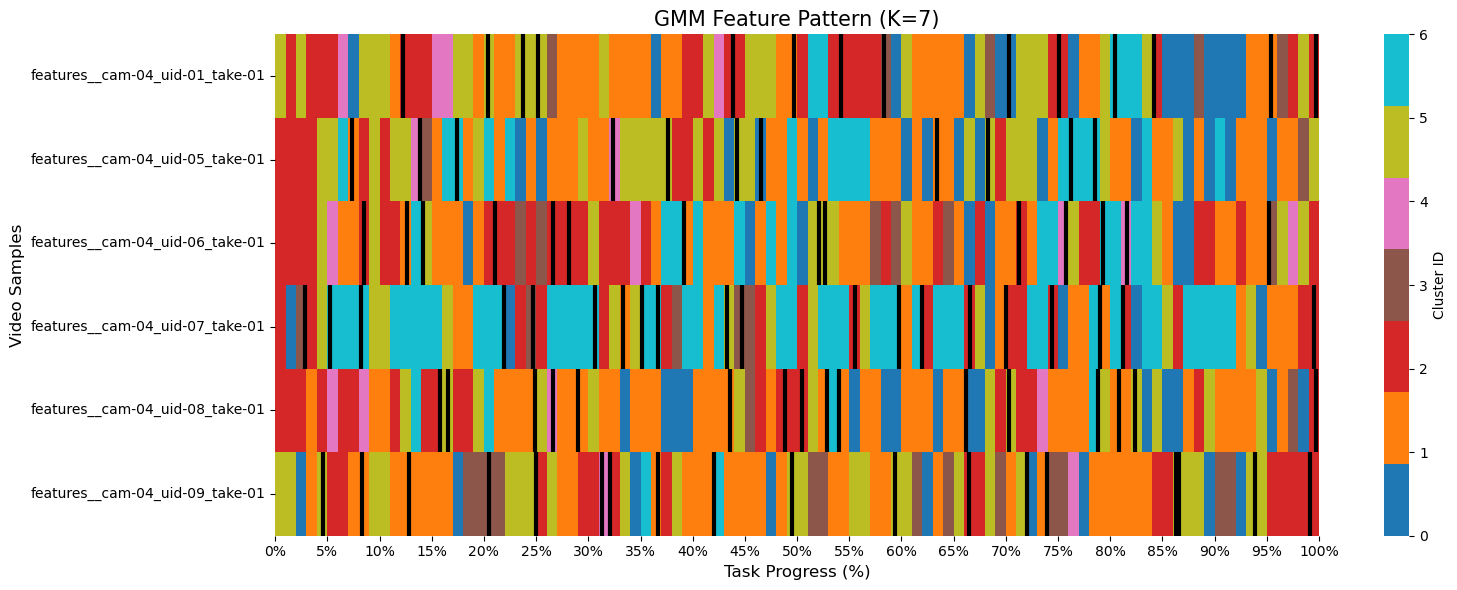

In [97]:
# joint angle
ax_joint, matrix_joint = plot_hybrid_feature_heatmap_pt(X_joint_scaled, pt_dir, n_clusters=7, target_steps=100) 

Performing GMM clustering (K=7)...


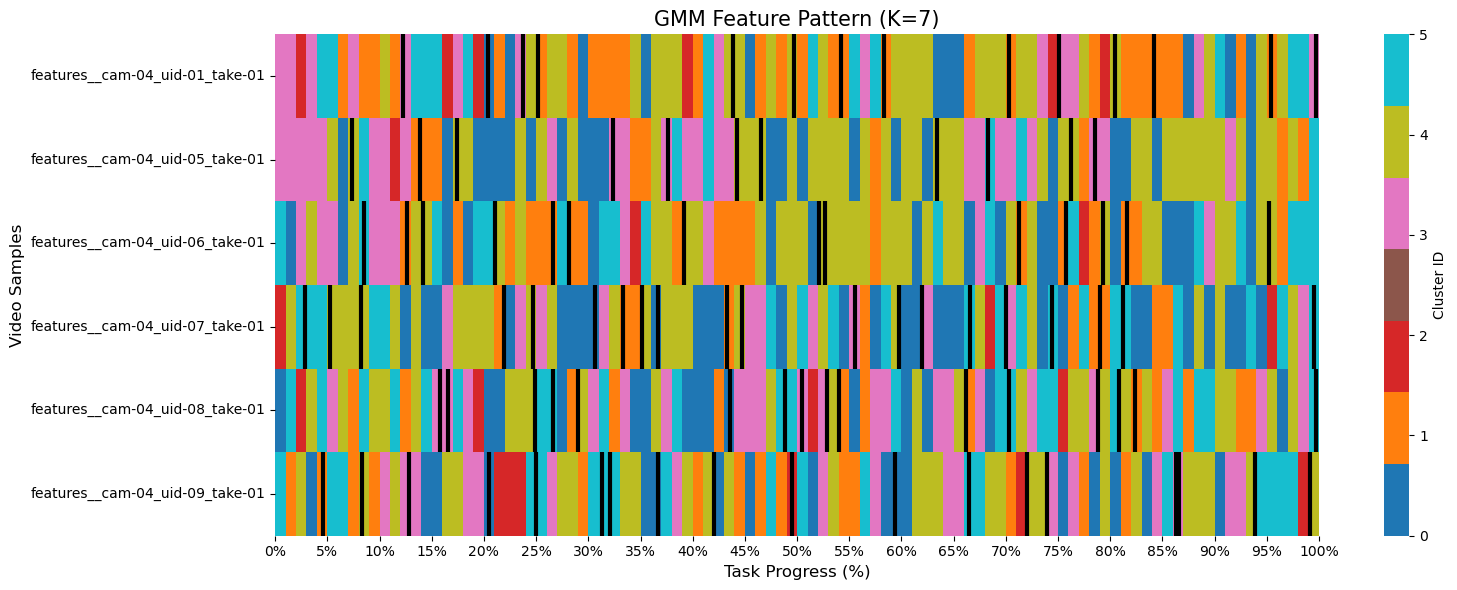

In [94]:
#acc
ax_acc, matrix_acc = plot_hybrid_feature_heatmap_pt(X_acc_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


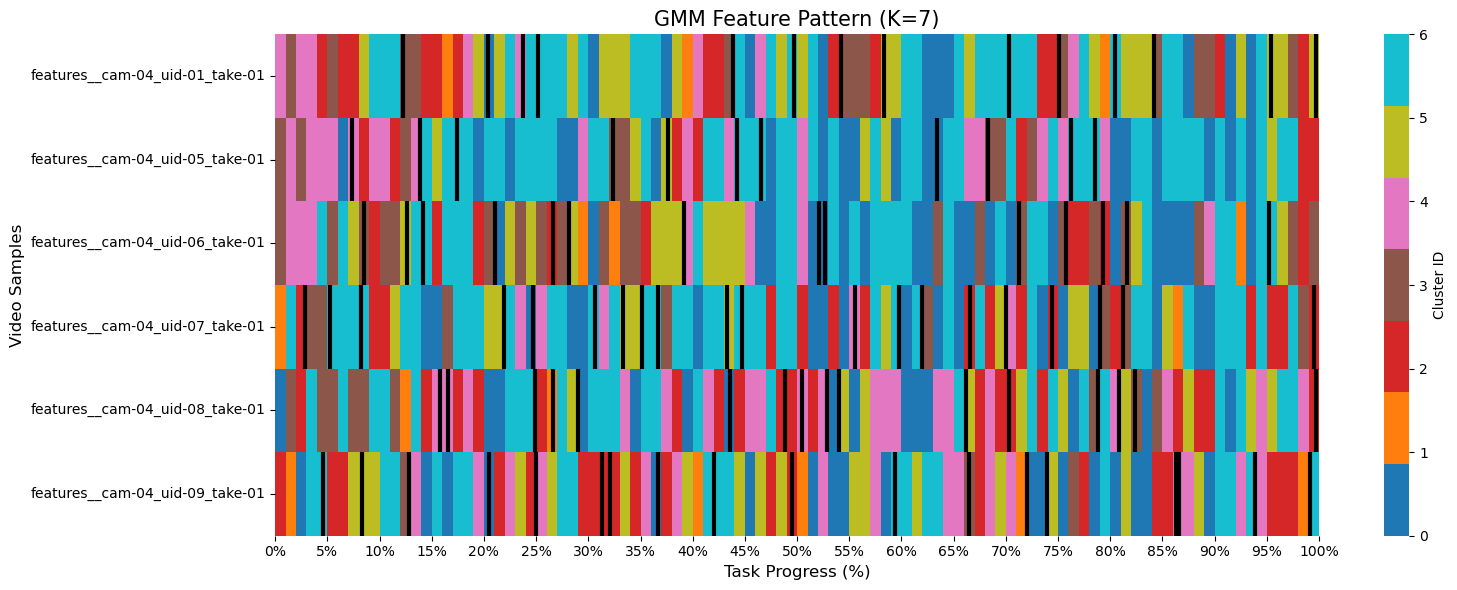

In [93]:
#vel:
ax_vel, matrix_vel = plot_hybrid_feature_heatmap_pt(X_vel_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


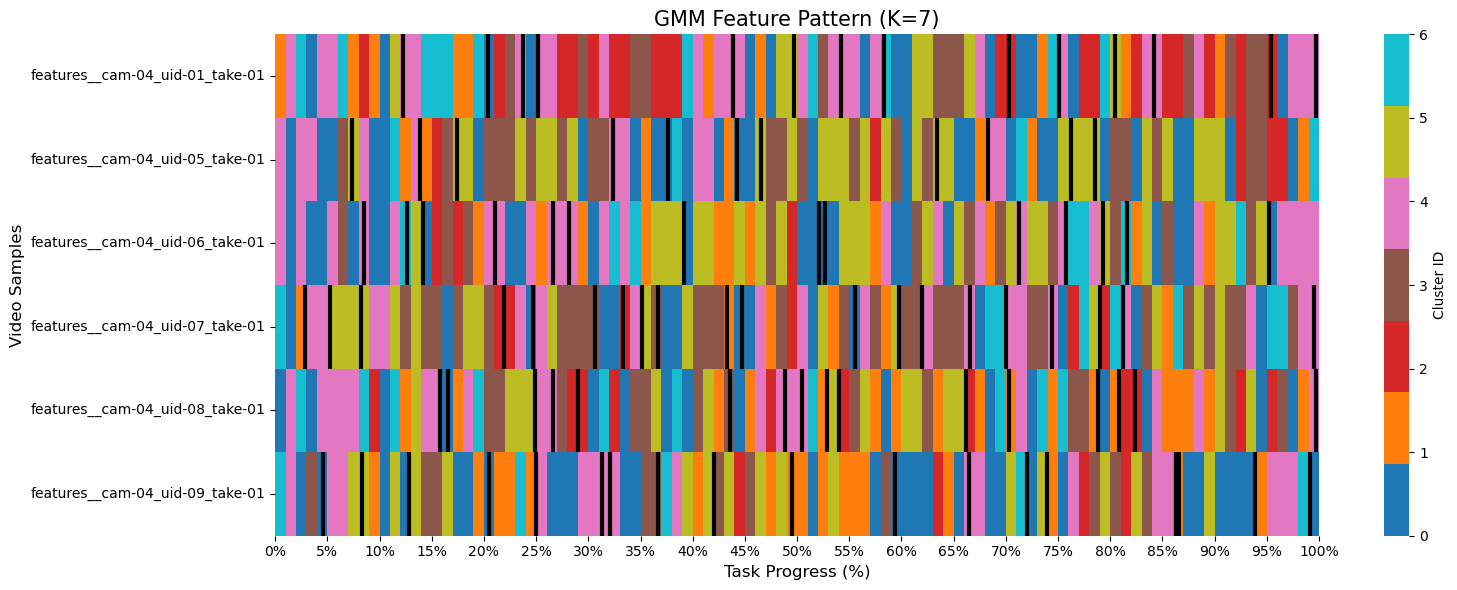

In [92]:
#acc + joint angle
ax_acc_joint, matrix_acc_joint = plot_hybrid_feature_heatmap_pt(X_acc_joint_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


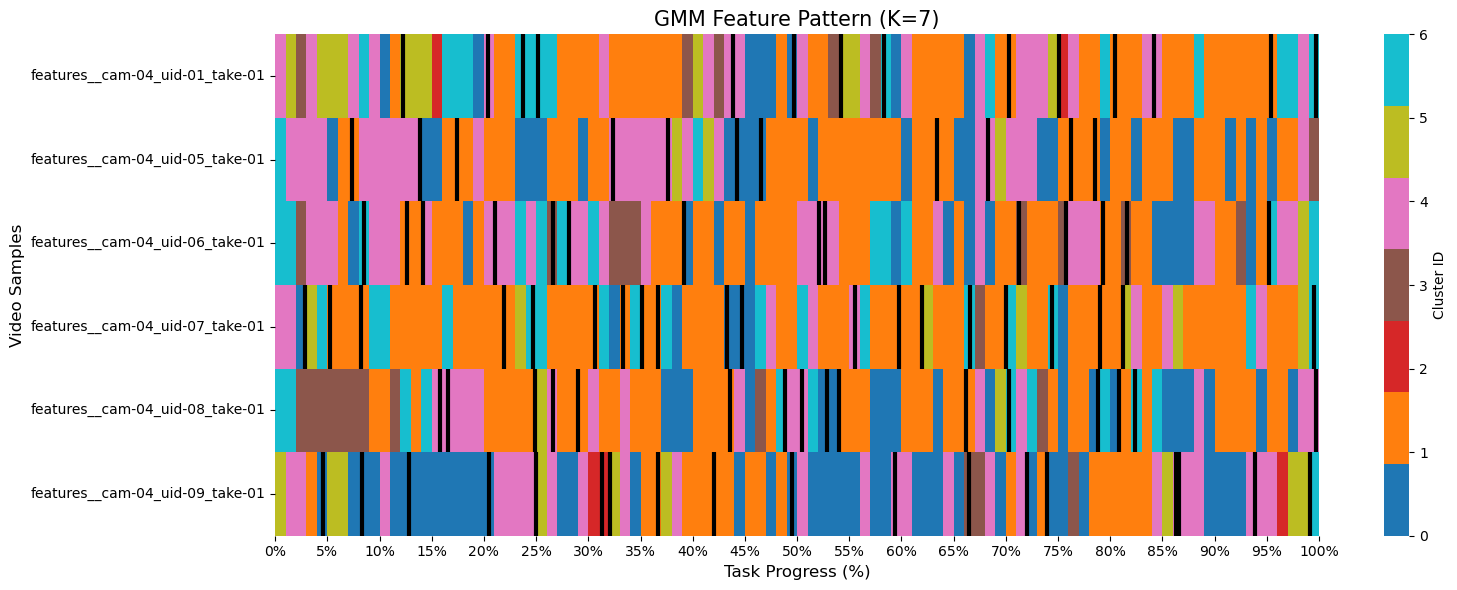

In [91]:
# combo:
ax_combo, matrix_combo = plot_hybrid_feature_heatmap_pt(X_combo_scaled, pt_dir, n_clusters=7, target_steps=100)

### CLUSTERING

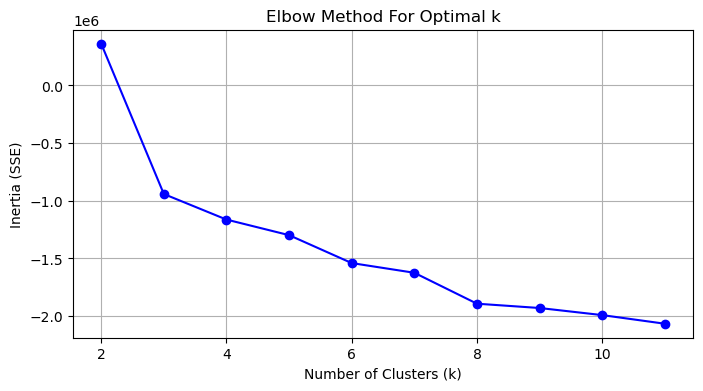

In [54]:
inertias = []
K_range = range(2, 12) #

X_stacked = X_combo_scaled  # Change this to analyze different feature combinations
X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

for k in K_range:
    # kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(X_scaled_deg_speed)
    # inertias.append(kmeans.inertia_)
    # GMMs
    gmm = GaussianMixture(
        n_components=k, 
        covariance_type='full', 
        random_state=42, 
        reg_covar=1e-6  # Added small value for numerical stability
    )
    
    # Fit the model and predict labels
    gmm.fit(X_stacked)
    inertias.append(gmm.bic(X_stacked))  # Using BIC for GMM instead of inertia

#
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [55]:

optimal_k = 8

gmm = GaussianMixture(
    n_components=optimal_k, 
    covariance_type='full', 
    random_state=42, 
    reg_covar=1e-6  # Added small value for numerical stability
)

# Fit the model and predict labels
labels = gmm.fit_predict(X_stacked)

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"cluster {i}: {c} {c/len(labels)*100:.1f}%")

cluster 0: 13730 16.3%
cluster 1: 617 0.7%
cluster 2: 15062 17.8%
cluster 3: 22537 26.7%
cluster 4: 4380 5.2%
cluster 5: 8225 9.7%
cluster 6: 15093 17.9%
cluster 7: 4822 5.7%


## TSNE visulization

In [ ]:
# from sklearn.manifold import TSNE
# import pandas as pd

# sample_size = 3000 
# indices = np.linspace(0, len(X_scaled_deg_speed_accel) - 1, sample_size).astype(int)
# X_sample = X_scaled_deg_speed_accel[indices]
# labels_sample = labels[indices]

# tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
# X_tsne = tsne.fit_transform(X_sample)


# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
#                       c=labels_sample, 
#                       cmap='tab10', 
#                       alpha=0.6, 
#                       s=15)


# legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
# plt.gca().add_artist(legend1)

# plt.title(f"t-SNE Visualization of Action Clusters (K={optimal_k})", fontsize=15)
# plt.xlabel("t-SNE dimension 1")
# plt.ylabel("t-SNE dimension 2")
# plt.grid(True, alpha=0.3)
# plt.show()

### Visulize Selected Postures of Each Cluster

In [29]:
def plot_skeleton(points, title, ax):
    EDGES = [
        # Face
        (0, 1), (0, 2), (1, 3), (2, 4), 
        # Upper Body & Arms
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
        # Torso
        (5, 11), (6, 12), (11, 12),
        # Lower Body & Legs
        (11, 13), (13, 15), (12, 14), (14, 16)
    ]
    pts = points.reshape(17, 2)
    ax.scatter(pts[:, 0], -pts[:, 1], c='red', s=20) 
    for edge in EDGES:
        ax.plot([pts[edge[0], 0], pts[edge[1], 0]], 
                 [-pts[edge[0], 1], -pts[edge[1], 1]], 'b-', linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.axis('equal')
    ax.axis('off') 

# find representative postures for each cluster and plot them
plt.figure(figsize=(20, 5))

# X_scaled_deg.shape[1] = 9
# X_pos.shape[1] = 22 (skeleton points)
# Reshaped XYN Features:     (61104, 34)
X_pos = X_xyn.reshape(-1, 17, 2)

for i in range(optimal_k):
    cluster_indices = np.where(labels == i)[0]
    
    if len(cluster_indices) > 0:
        cluster_postures = X_pos[cluster_indices]

        representative_posture = np.mean(cluster_postures, axis=0)
        
        ax = plt.subplot(1, optimal_k, i+1)
        
        percentage = (len(cluster_indices) / len(labels)) * 100
        title_str = f"Cluster {i}\n({percentage:.1f}%)"
        
        plot_skeleton(representative_posture, title_str, ax)
    else:
        print(f"Warning: Cluster {i} has no samples.")

plt.suptitle("Representative Postures Derived from Degree-based Clustering", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

NameError: name 'X_xyn' is not defined

<Figure size 2000x500 with 0 Axes>

## Conclusions:

## 1. Feature selection and combination

## 2. Posture cluster and step segmentation